<a href="https://colab.research.google.com/github/sayanasurendran04/Housing-Price-Prediction/blob/main/Housing_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 

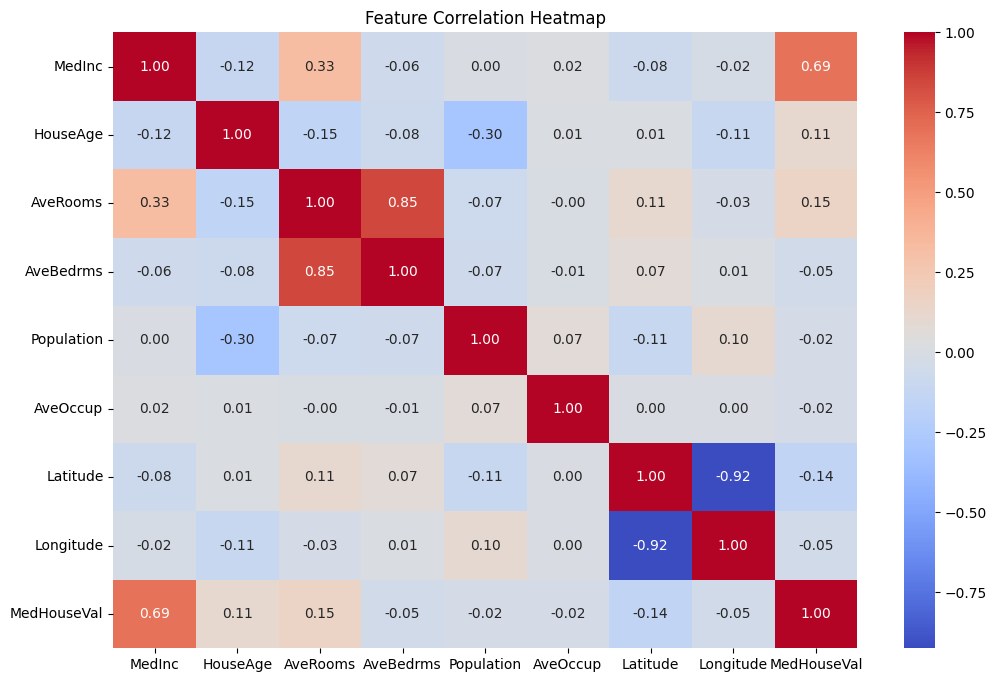

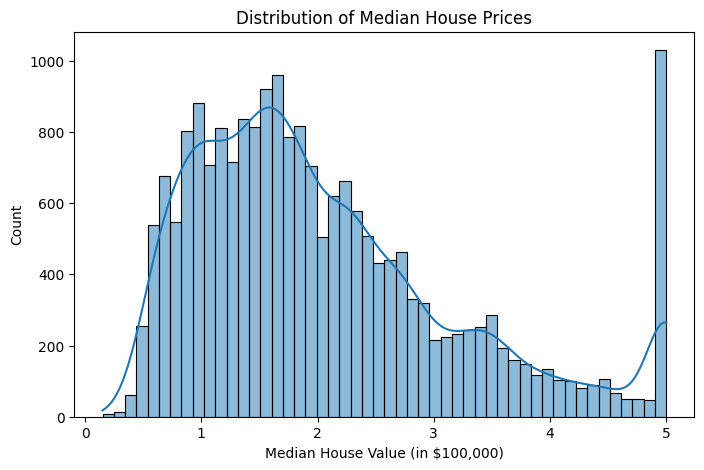

Training samples: 16512
Testing samples: 4128

=== Model Performance Comparison ===
                      MAE     MSE    RMSE  R² Score
Linear Regression  0.5332  0.5559  0.7456    0.5758
Ridge Regression   0.5332  0.5558  0.7455    0.5759
Lasso Regression   0.5816  0.6135  0.7833    0.5318
Random Forest      0.3275  0.2554  0.5053    0.8051


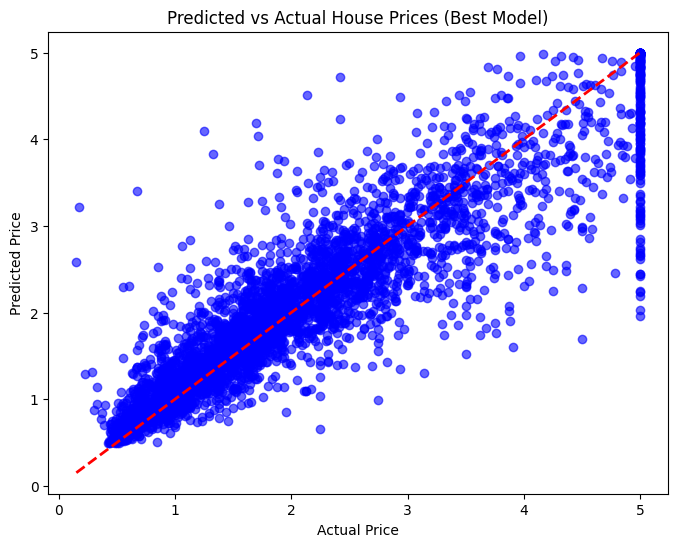

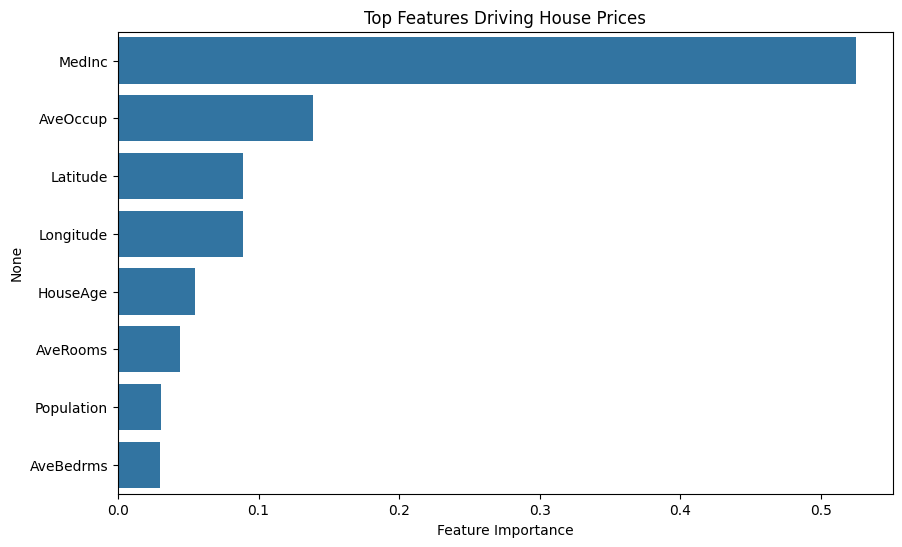


=== Top Features Driving House Price ===
MedInc        0.524871
AveOccup      0.138443
Latitude      0.088936
Longitude     0.088629
HouseAge      0.054593
AveRooms      0.044272
Population    0.030650
AveBedrms     0.029606
dtype: float64

✅ Model saved as 'housing_price_model.pkl' for future deployment!


In [3]:
# =============================================
# PROJECT 1: Housing Price Prediction (Regression)
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# ------------------- 1. Load Dataset -------------------
data = fetch_california_housing(as_frame=True)
df = data.frame

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

# ------------------- 2. Check Missing Values -------------------
print("\nMissing Values:\n", df.isnull().sum())

# ------------------- 3. Exploratory Data Analysis -------------------
# Feature Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Distribution of Target Variable (Median House Value)
plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title('Distribution of Median House Prices')
plt.xlabel('Median House Value (in $100,000)')
plt.show()

# ------------------- 4. Prepare Data -------------------
X = df.drop('MedHouseVal', axis=1)   # Features
y = df['MedHouseVal']                # Target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# ------------------- 5. Train Multiple Models -------------------
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R² Score": r2_score(y_test, y_pred)
    }

# ------------------- 6. Compare Models -------------------
results_df = pd.DataFrame(results).T.round(4)
print("\n=== Model Performance Comparison ===")
print(results_df)

# ------------------- 7. Best Model (Random Forest) -------------------
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# Predicted vs Actual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual House Prices (Best Model)')
plt.show()

# ------------------- 8. Feature Importance (Conclusion) -------------------
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top Features Driving House Prices')
plt.xlabel('Feature Importance')
plt.show()

print("\n=== Top Features Driving House Price ===")
print(importances)

# ------------------- Stretch: Save Model -------------------
joblib.dump(best_model, 'housing_price_model.pkl')
print("\n✅ Model saved as 'housing_price_model.pkl' for future deployment!")